24RB1074　半田悠人

## 課題：PCA vs ランダム射影

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

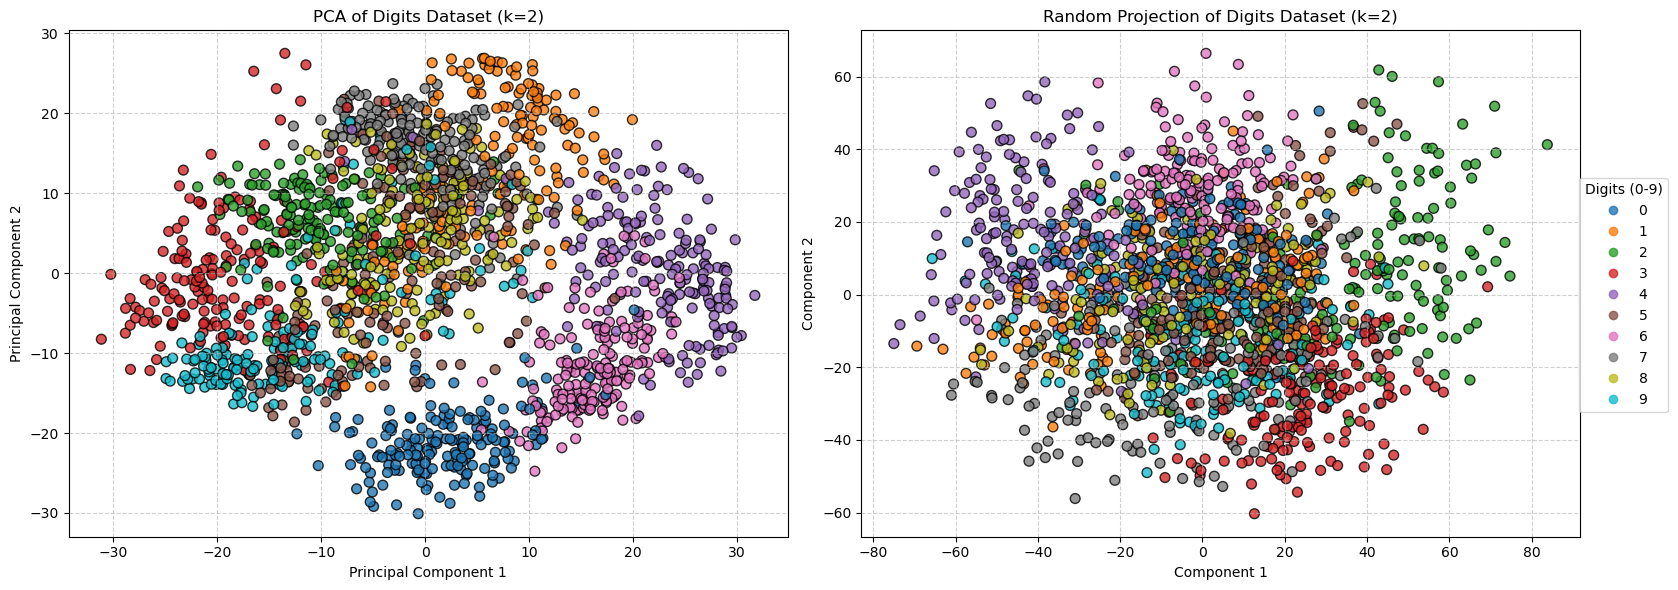

In [2]:

# 1. データの読み込みと中心化
X, y = load_digits(return_X_y=True)
X_centered = X - np.mean(X, axis=0)

# 2. PCAによる次元圧縮 (k=2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_centered)

# 3. ランダム射影による次元圧縮 (k=2)
def make_A(X, k=2):
    d = X.shape[1]
    A = np.random.normal(loc=0.0, scale=np.sqrt(1/k), size=(k, d))
    return A

np.random.seed(42) 
A = make_A(X_centered, k=2)
X_random = X_centered @ A.T  

# 4. 横に並べてプロット (1行2列のキャンバスを作成)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左側：PCA ---
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', edgecolor='k', s=50, alpha=0.8)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].set_title('PCA of Digits Dataset (k=2)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- 右側：ランダム射影 ---
# c=y で正解ラベルごとに色分け
scatter2 = axes[1].scatter(X_random[:, 0], X_random[:, 1], c=y, cmap='tab10', edgecolor='k', s=50, alpha=0.8)
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
axes[1].set_title('Random Projection of Digits Dataset (k=2)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# グラフの外側に共通の凡例を追加
handles, labels = scatter1.legend_elements()
fig.legend(handles, labels, title="Digits (0-9)", loc="center right", bbox_to_anchor=(1.05, 0.5))

# レイアウトを整えて表示
plt.tight_layout()
plt.show()

### クラスタ分離の違い
* **PCA** 各数字のデータがまとまり、色ごとのクラスターが確認できる。
* **ランダム射影** すべての数字のデータが画面全体に重なり合い、色ごとのクラスター構造は確認できない。

これらの違いは、射影軸の選び方が、元データの情報をどれだけ保持したまま次元を削減できるかに起因するものである。PCAはデータの分散が最大になる方向を選択して射影軸を決定するため、2次元という極端に低い次元に圧縮しても、クラスター構造を保持しやすい。

一方で、ランダム射影は、完全にランダムな軸を用いて射影を作る手法である。Johnson-Lindenstrauss補題によれば、十分な次元数に射影すれば点間の距離関係は高確率で保たれるが、今回のように極端に低い次元への射影では、JL補題の条件を満たさず、クラスター構造は完全に潰れてしまうことが確認できた。